# **Credit_Card_Fraud_Detection_Using_Random_Forest**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import zipfile
zip=zipfile.ZipFile('/content/drive/MyDrive/Data Science/Project/CreditCard.zip')
zip.extractall()
zip.close()

In [ ]:
import keras

np.random.seed(2)

In [ ]:
data=pd.read_csv('/content/creditcard.csv')

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Pre-Processing**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
data['normalizedAmount']=sc.fit_transform(data['Amount'].values.reshape(-1,1))

In [ ]:
data.drop('Amount',axis=1,inplace=True)

In [ ]:
data.drop('Time',axis=1,inplace=True)

In [ ]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,normalizedAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


In [ ]:
X=data.drop('Class',axis=1)

In [ ]:
y=data['Class']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=123)

In [21]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,normalizedAmount
99168,-0.866221,-0.919624,2.020857,-1.525794,-1.035785,2.157966,-0.281997,0.608243,-0.595195,-0.192038,...,0.658829,0.511087,1.154578,-0.070794,-1.678518,0.511949,0.159084,0.044666,0.063497,0.562332
69460,0.967267,-0.179598,0.315800,1.354288,-0.273647,0.139429,-0.005874,0.174708,0.195502,0.040867,...,-0.090995,-0.015079,-0.078930,-0.131669,-0.001284,0.565061,-0.334174,0.013635,0.017108,-0.001598
71073,-0.415673,1.080659,0.675844,0.789318,0.158613,0.430765,0.135873,0.671417,-1.000854,-0.298512,...,-0.163889,0.287891,0.782205,0.004812,-0.271442,-0.301717,-0.287004,-0.015223,-0.034233,-0.289660
275238,2.036473,-0.021870,-1.085398,0.500278,-0.106741,-1.226224,0.187898,-0.399751,0.320678,0.163216,...,-0.139006,0.159477,0.583649,0.091193,0.111583,0.003484,0.378828,-0.055797,-0.056548,-0.285102
208891,-4.420316,-3.367604,3.339102,6.050951,2.641524,0.359443,-4.793559,-1.765357,-0.387127,1.087007,...,0.174084,-1.341109,1.123252,-0.526044,0.180769,0.032032,0.687107,0.850304,-0.142814,0.156766


In [ ]:
X_train.shape

(227845, 29)

In [ ]:
X_test.shape

(56962, 29)

**Random Forest**

In [26]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)

RandomForestClassifier()

In [27]:
y_pred=model.predict(X_test)

<Axes: >

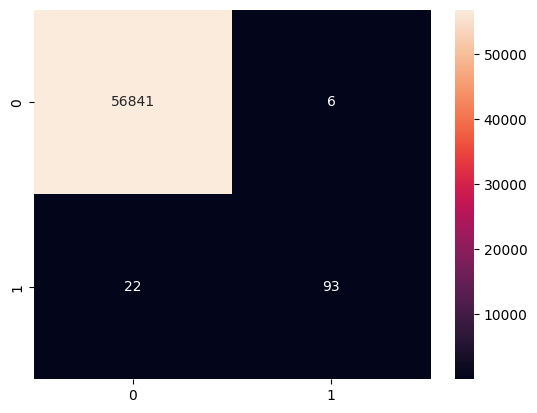

In [28]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')

In [29]:
y_pred=model.predict(X)

<Axes: >

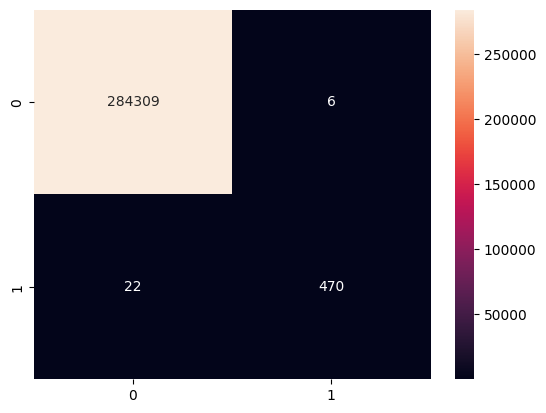

In [30]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,y_pred)
sns.heatmap(cm,annot=True,fmt='d')